Import Libraries to get things running 

In [1]:
import seaborn as sns 
import matplotlib.pyplot as plt 
import numpy as np 
import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error,r2_score
from sklearn.preprocessing import PolynomialFeatures, StandardScaler #standard Scaler helpful with big values 


Loading and Cleaning Columns and rows

In [2]:
df = pd.read_csv('crop_yield_polynomial_regression.csv')
df.columns= df.columns.str.lower().str.strip()
df = df.dropna(axis=1, how='all') #it will select and remove all those empty Columns(axis=1) which have everything null (how = 'all')
numerical_cols = ['fertilizer_kg_per_hectare','water_mm_per_season','pesticide_l_per_hectare','cropyield_tons']
for col in numerical_cols:
    df[col]= pd.to_numeric(df[col],errors = 'coerce')
print(f"\nBefore:\n{df.isnull().sum()}\n")
df = df.dropna(subset=['cropyield_tons'])

for col in ['fertilizer_kg_per_hectare','water_mm_per_season','pesticide_l_per_hectare']:
    df[col]=df[col].fillna(df[col].median())

print("\nColumn names:", df.columns.tolist())
print(f"\nMissing values after adding Medians:\n{df.isnull().sum()}")
print(f"Data cleaned with outliers : {df.shape}")



#info showed some outliers which will put noise in model so cleaning is needed.
df= df[df['fertilizer_kg_per_hectare']>=0]
df= df[df['fertilizer_kg_per_hectare']<=400]
df= df[df['water_mm_per_season']>=0]
df= df[df['water_mm_per_season']<=2000]
df= df[df['pesticide_l_per_hectare']>=0]
df= df[df['pesticide_l_per_hectare']<=15]
df= df[df['cropyield_tons']>=0]


# 6. One-Hot Encoding for Crop Type it will make three rooms to divide records from string that shows category of crop
df = pd.get_dummies(df, columns=['croptype'], drop_first=True, dtype=int)

print("Data fully cleaned! Shape:", df.shape)
print("\nFinal column names:", df.columns.tolist())





Before:
croptype                      0
fertilizer_kg_per_hectare    17
water_mm_per_season          15
pesticide_l_per_hectare      12
cropyield_tons                8
dtype: int64


Column names: ['croptype', 'fertilizer_kg_per_hectare', 'water_mm_per_season', 'pesticide_l_per_hectare', 'cropyield_tons']

Missing values after adding Medians:
croptype                     0
fertilizer_kg_per_hectare    0
water_mm_per_season          0
pesticide_l_per_hectare      0
cropyield_tons               0
dtype: int64
Data cleaned with outliers : (492, 5)
Data fully cleaned! Shape: (483, 7)

Final column names: ['fertilizer_kg_per_hectare', 'water_mm_per_season', 'pesticide_l_per_hectare', 'cropyield_tons', 'croptype_Rice', 'croptype_Soybean', 'croptype_Wheat']


In [3]:

features = ['fertilizer_kg_per_hectare','water_mm_per_season','pesticide_l_per_hectare','cropyield_tons','croptype_Rice','croptype_Soybean','croptype_Wheat']

X =  df[features]
y = df['cropyield_tons']

X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.33 ,random_state= 42)
#lets go with degree 2 
degree =2
poly = PolynomialFeatures(degree= degree, include_bias= False)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Let's see how many features were created! (It will be a lot more than 6)
print(f"\nOriginal features: {len(features)}")
print(f"Polynomial features created: {X_train_poly.shape[1]}")


Original features: 7
Polynomial features created: 35


In [4]:

results = []

for degree in range(1,13):
    poly = PolynomialFeatures(degree= degree ,include_bias=False)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    scaler = StandardScaler()
    X_train_poly_scaled = scaler.fit_transform(X_train_poly)
    X_test_poly_scaled = scaler.transform(X_test_poly)

    model = LinearRegression()
    model.fit(X_train_poly_scaled, y_train)

    y_pred = model.predict(X_test_poly_scaled)
        
    train_r2 = model.score(X_train_poly_scaled, y_train)
    test_r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    
    results.append({
        'Degree': degree,
        'Train R2': train_r2,
        'Test R2': test_r2,
        'MAE': mae,
        'MSE': mse,
        'Features Created': X_train_poly.shape[1]
    })
    
results_df = pd.DataFrame(results)
# Create a copy for clean formatting
formatted_df = results_df.copy()

# Format floats to 6 decimal places and large integers with commas
pd.set_option('display.float_format', lambda x: f'{x:.6f}')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Print with a beautiful text-based grid layout
print(formatted_df.to_string(index=False))

    



 Degree  Train R2  Test R2      MAE      MSE  Features Created
      1  1.000000 1.000000 0.000000 0.000000                 7
      2  1.000000 1.000000 0.000000 0.000000                35
      3  1.000000 1.000000 0.000000 0.000000               119
      4  1.000000 1.000000 0.000000 0.000000               329
      5  1.000000 0.999999 0.000354 0.000001               791
      6  1.000000 0.999991 0.001304 0.000017              1715
      7  1.000000 0.999898 0.004420 0.000200              3431
      8  1.000000 0.999540 0.009244 0.000903              6434
      9  1.000000 0.998253 0.016744 0.003428             11439
     10  1.000000 0.994211 0.027790 0.011355             19447
     11  1.000000 0.982981 0.043123 0.033382             31823
     12  1.000000 0.955122 0.063522 0.088028             50387


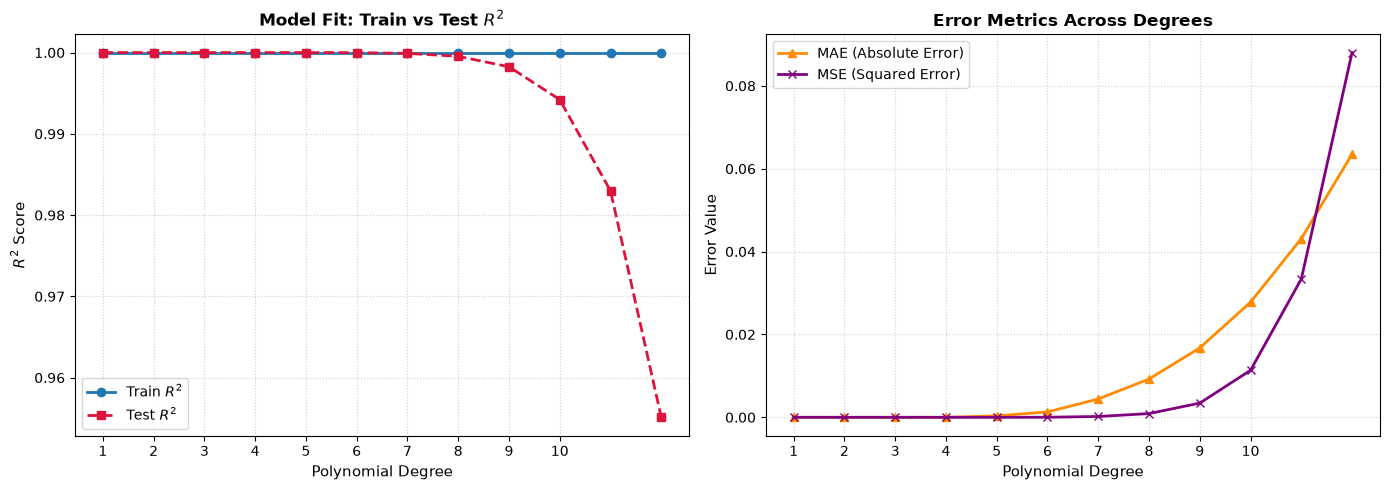

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: R-squared Scores (Train vs Test)
ax1.plot(
    results_df["Degree"],
    results_df["Train R2"],
    label="Train $R^2$",
    marker="o",
    linewidth=2,
)
ax1.plot(
    results_df["Degree"],
    results_df["Test R2"],
    label="Test $R^2$",
    marker="s",
    linestyle="--",
    linewidth=2,
    color="crimson",
)
ax1.set_xlabel("Polynomial Degree", fontsize=11)
ax1.set_ylabel("$R^2$ Score", fontsize=11)
ax1.set_title("Model Fit: Train vs Test $R^2$", fontsize=12, fontweight="bold")
ax1.set_xticks(range(1, 11))
ax1.grid(True, linestyle=":", alpha=0.6)
ax1.legend(fontsize=10)

# Plot 2: Error Evaluation (MAE and MSE)
ax2.plot(
    results_df["Degree"],
    results_df["MAE"],
    label="MAE (Absolute Error)",
    marker="^",
    color="darkorange",
    linewidth=2,
)
ax2.plot(
    results_df["Degree"],
    results_df["MSE"],
    label="MSE (Squared Error)",
    marker="x",
    color="purple",
    linewidth=2,
)
ax2.set_xlabel("Polynomial Degree", fontsize=11)
ax2.set_ylabel("Error Value", fontsize=11)
ax2.set_title("Error Metrics Across Degrees", fontsize=12, fontweight="bold")
ax2.set_xticks(range(1, 11))
ax2.grid(True, linestyle=":", alpha=0.6)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.savefig("polynomial_regression_results.png", dpi=300, bbox_inches="tight")
plt.show()

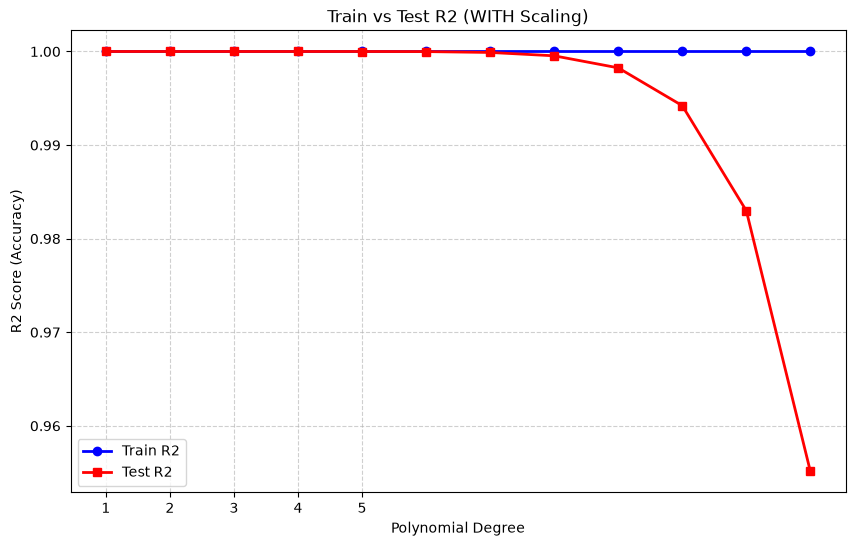

In [6]:
plt.figure(figsize=(10, 6))
plt.plot(results_df['Degree'], results_df['Train R2'], 'o-', color='blue', label='Train R2', linewidth=2)
plt.plot(results_df['Degree'], results_df['Test R2'], 's-', color='red', label='Test R2', linewidth=2)
plt.xlabel("Polynomial Degree")
plt.ylabel("R2 Score (Accuracy)")
plt.title("Train vs Test R2 (WITH Scaling)")
plt.xticks(range(1, 6))
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()